Функции:

In [1]:
def edit_names_columns(df):
    
    """Переводит имена столбцов в нижний регистр, удаляет пробелы в начале и конце имени, 
    заменяет пробелы на знак нижнего подчеркивания"""
    
    df.columns = [x.lower().strip().replace(' ', '_') for x in df.columns]
    print(df.columns)

In [2]:
def print_model_result(grids, data_times, model_name, process_print=False):
    print()
    print('Модель         :', model_name)
    print('Метрика ROC AUC:', grids[-1].best_score_)
    print(f'Время          : {data_times[-1]} секунд')
    print('Параметры      :', grids[-1].best_estimator_[-1].get_params())
    print()
    if process_print:
        print('Результаты выбора параметров модели:')
        results_df = pd.DataFrame(grids[-1].cv_results_)
        
        if 'mean_train_score' in results_df.columns and 'mean_test_score' in results_df.columns:
            display(results_df[['params', 'mean_train_score', 'mean_test_score']])
        else:
            print('Показатели "mean_train_score" и "mean_test_score" отсутствуют в результатах выбора параметров модели.')
    print('-' * 30)

In [3]:
def model_pipeline_gridsearch(features_train, target_train, pipeline, params, data_grids, data_times):
    start_time = time.time()

    grid = GridSearchCV(
        pipeline,
        params,
        cv=4,
        scoring='roc_auc',
        error_score='raise',
        return_train_score=True
    )

    grid.fit(features_train, target_train)
    
    finish_time = time.time()
    funtion_time = finish_time - start_time

    data_grids.append(grid)
    data_times.append(funtion_time) 

    return data_grids, data_times

In [4]:
def print_model_graphicresult(grids):
    pd.DataFrame(grids[-1].cv_results_)[['mean_test_score', 'mean_train_score']].plot()
    plt.show()

#    Описание проекта: телекоммуникации

    Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. 
    Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах.   

   Наша задача — обучить на данных заказчика модель для прогноза оттока клиентов.

   Описание услуг
   
 Оператор предоставляет два основных типа услуг: 
Стационарную телефонную связь. Телефон можно подключить к нескольким линиям одновременно.
Интернет. Подключение может быть двух типов: через телефонную линию (DSL, от англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (Fiber optic).
 Также доступны такие услуги:
Интернет-безопасность: антивирус (DeviceProtection) и блокировка небезопасных сайтов (OnlineSecurity);
Выделенная линия технической поддержки (TechSupport);
Облачное хранилище файлов для резервного копирования данных (OnlineBackup);
Стриминговое телевидение (StreamingTV) и каталог фильмов (StreamingMovies).

Клиенты могут платить за услуги каждый месяц или заключить договор на 1–2 года. Возможно оплатить счёт разными способами, а также получить электронный чек.

  Описание данных
  
Данные состоят из нескольких файлов, полученных из разных источников:
contract_new.csv — информация о договоре;
personal_new.csv — персональные данные клиента;
internet_new.csv — информация об интернет-услугах;
phone_new.csv — информация об услугах телефонии.

Файл contract_new.csv
customerID — идентификатор абонента;
BeginDate — дата начала действия договора;
EndDate — дата окончания действия договора;
Type — тип оплаты: раз в год-два или ежемесячно;
PaperlessBilling — электронный расчётный лист;
PaymentMethod — тип платежа;
MonthlyCharges — расходы за месяц;
TotalCharges — общие расходы абонента.

Файл personal_new.csv
customerID — идентификатор пользователя;
gender — пол;
SeniorCitizen — является ли абонент пенсионером;
Partner — есть ли у абонента супруг или супруга;
Dependents — есть ли у абонента дети.

Файл internet_new.csv
customerID — идентификатор пользователя;
InternetService — тип подключения;
OnlineSecurity — блокировка опасных сайтов;
OnlineBackup — облачное хранилище файлов для резервного копирования данных;
DeviceProtection — антивирус;
TechSupport — выделенная линия технической поддержки;
StreamingTV — стриминговое телевидение;
StreamingMovies — каталог фильмов.

Файл phone_new.csv
customerID — идентификатор пользователя;
MultipleLines — подключение телефона к нескольким линиям одновременно.

Во всех файлах столбец customerID содержит код клиента. Информация о договорах актуальна на 1 февраля 2020 года.
Данные также находятся в тренажёре, в папке /datasets/.

План работы

  Шаг 1. Загрузка данных
 Загрузим данные и выполним их первичный осмотр.

  Шаг 2. Исследовательский анализ и предобработка данных
 Выполним исследовательский анализ каждого датафрейма и при необходимости выполним предобработку. 
 Сделаем выводы об имеющихся признаках: понадобятся ли они для обучения моделей.

  Шаг 3. Объединение данных
 Объединим выбранные нами признаки в один датафрейм по ключу.

  Шаг 4. Исследовательский анализ и предобработка данных объединённого датафрейма
 Выполним исследовательский анализ объединённого датафрейма, визуализируем распределения признаков и при необходимости выполним предобработку. 
 Проведем корреляционный анализ. 
 Помним, что мы можем использовать не только имеющиеся признаки, но и генерировать новые.

  Шаг 5. Подготовка данных
 Выполним подготовку данных для обучения модели. 
 Разделим данные на две выборки, при масштабировании и кодировании учтем особенности данных и моделей.

  Шаг 6. Обучение моделей машинного обучения
 Обучим как минимум две модели. Хотя бы для одной из них подберем как минимум два гиперпараметра.

  Шаг 7. Выбор лучшей модели
 Выберем лучшую модель и проверим её качество на тестовой выборке.

  Шаг 8. Общий вывод и рекомендации заказчику
 Сделаем общий вывод о проделанной работе: опишем основные этапы работы, полученные результаты и дадим рекомендации для бизнеса.

## Шаг 1. Загрузка данных

### Загрузим данные и выполним их первичный осмотр.

In [5]:
!pip uninstall -y pandas numpy scikit-learn

Found existing installation: pandas 1.2.4
Uninstalling pandas-1.2.4:
  Successfully uninstalled pandas-1.2.4
Found existing installation: numpy 1.21.1
Uninstalling numpy-1.21.1:
  Successfully uninstalled numpy-1.21.1
Found existing installation: scikit-learn 0.24.1
Uninstalling scikit-learn-0.24.1:
  Successfully uninstalled scikit-learn-0.24.1


In [6]:
!pip install -U pandas numpy scikit-learn

     |████████████████████████████████| 13.1 MB 2.6 MB/s eta 0:00:01     |███████████████████████████▏    | 11.1 MB 2.6 MB/s eta 0:00:01
     |████████████████████████████████| 19.3 MB 113.4 MB/s eta 0:00:01
     |████████████████████████████████| 13.4 MB 79.6 MB/s eta 0:00:01
     |████████████████████████████████| 345 kB 89.6 MB/s eta 0:00:01
     |████████████████████████████████| 229 kB 112.2 MB/s eta 0:00:01
     |████████████████████████████████| 301 kB 103.1 MB/s eta 0:00:01
     |████████████████████████████████| 17.3 MB 73.4 MB/s eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.20.1
    Uninstalling numpy-1.20.1:
      Successfully uninstalled numpy-1.20.1
  Attempting uninstall: python-dateutil
    Found existing installation: python-dateutil 2.8.1
    Uninstalling python-dateutil-2.8.1:
      Successfully uninstalled python-dateutil-2.8.1
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1

In [7]:
# Обновление библиотек

# Ядро тетради требует обновление этого модуля
!pip install -U pyodbc

!pip install -U numpy
!pip install -U pandas
!pip install -U scikit-learn

     |████████████████████████████████| 331 kB 2.6 MB/s eta 0:00:01
  Using cached numpy-2.0.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.9.1 requires numpy<1.25.0,>=1.18.5, but you have numpy 2.0.0 which is incompatible.
numba 0.56.0 requires numpy<1.23,>=1.18, but you have numpy 2.0.0 which is incompatible.
  Using cached numpy-1.24.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.0
    Uninstalling numpy-2.0.0:
      Successfully uninstalled numpy-2.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages t

In [8]:
# Загрузка новых библиотек

!pip install -U pandas numpy scikit-learn
# Анализ мультиколлинеарности
!pip install phik
# CatBoost - CatBoosting от Яндекс
!pip install catboost
# pytest - требуется для использования statsmodels.stats.tests.test_influence
!pip install pytest

  Using cached numpy-2.0.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.3 MB)
     |████████████████████████████████| 686 kB 1.3 MB/s eta 0:00:01
     |████████████████████████████████| 339 kB 1.2 MB/s eta 0:00:01


In [9]:
# Базовые библиотеки
import numpy as np
import pandas as pd

# Вспомогательные библиотеки
import os # Загрузка датафрейма
import time # Оценка времени выполнения кода
import re # Изменение названий столбцов
from scipy import stats #  тесты на статистическую значимость

# Работа с датафреймом
from sklearn.model_selection import(
    GridSearchCV, 
    train_test_split # Автоматическое разделение датафреймов на трейн и тест
)

# Предобработка данных
from sklearn.preprocessing import(
    MaxAbsScaler, # стандартизация по максимальному абсолютном значению в пределах 0-1
    PowerTransformer, # Приведение к нормальному распределению
    OneHotEncoder, # OHE кодирование для "линейных" моделей с созданием отдельных столбцов для каждого категориального значения, drop='first' (удаление первого столбца против dummy-ловушки), sparse=False (?)
    OrdinalEncoder # порядковое кодирование для "деревянных" моделей
) 


# Автоматизация раздельного декодирования признаков
from sklearn.compose import(
    make_column_transformer, 
    ColumnTransformer
)

# Pipeline (пайплайн)
from sklearn.pipeline import Pipeline
# Функция для поддержки экспериментальной функции HavingGridSearchSV
from sklearn.experimental import enable_halving_search_cv
# Ускоренная автоматизация поиска лучших моделей и их параметров
from sklearn.model_selection import HalvingGridSearchCV
# Предоставляет функциональность по стандартизации признаков путем удаления среднего и масштабирования до единичной дисперсии
from sklearn.preprocessing import StandardScaler

# Модели
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier # Случайный лес. Классификация
from sklearn.naive_bayes import ComplementNB # Улучшенный классификатор для не сбалансированных классов
from catboost import CatBoostClassifier # CatBoost (Яндекс). Классификация# LightGBM
from sklearn.dummy import DummyRegressor, DummyClassifier # модель Dummy на адекватность

# Метрики
from sklearn.metrics import(
    roc_curve, # Кривая "ROC"
    auc, # Параметр "AUC" 
    roc_auc_score, # Площадь под кривой рабочих характеристик приемника "ROC AUC"
    accuracy_score, # Accuracy 
    confusion_matrix, # Матрица "путаницы" для матрицы ошибок
    ConfusionMatrixDisplay # Матрица ошибок
) 

# Анализ мультиколлениарности
import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix

# Визуализация графиков
import seaborn as sns
import matplotlib
%matplotlib inline
from matplotlib import pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from pandas.plotting import scatter_matrix

In [10]:
# Отображение всех столбцов таблицы
pd.set_option('display.max_columns', None)
# Обязательно для нормального отображения графиков plt
rcParams['figure.figsize'] = 10, 6
%config InlineBackend.figure_format = 'svg'
# Дополнительно и не обязательно для декорирования графиков
factor = .8
default_dpi = rcParamsDefault['figure.dpi']
rcParams['figure.dpi'] = default_dpi * factor

#### ГЛОБАЛЬНЫЕ ПЕРЕМЕННЫЕ

In [11]:
# Глобальная константа для фиксации случайных значений
RANDOM_STATE = 170624

In [12]:
# Функция загрузки данных из файлов в датафреймы
def read_files(file_name):
    
    data = pd.DataFrame()
    
    path_1 = 'datasets/' + file_name + '.csv'
    path_2 = '/datasets/' + file_name + '.csv'
    path_3 = 'https://code.s3.yandex.net/datasets/' + file_name + '.csv'
    
    if os.path.exists(path_1):
        data = pd.read_csv(path_1)
    elif os.path.exists(path_2):
        data = pd.read_csv(path_2)
    elif os.path.exists(path_3):
        data = pd.read_csv(path_3)
    
    return data

In [13]:
# Загрузка файла "contract_new.csv" — информация о договоре
contract_new = read_files('contract_new')

# Анализ данных из файла
contract_new.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5


In [14]:
# Загрузка файла "personal_new.csv" — персональные данные клиента
personal_new = read_files('personal_new')

# Анализ данных из файла
personal_new.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [15]:
# Загрузка файла "internet_new.csv" — информация об интернет-услугах
internet_new = read_files('internet_new')

# Анализ данных из файла
internet_new.head()

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [16]:
# Загрузка файла "phone_new.csv" — информация об услугах телефонии
phone_new = read_files('phone_new')

# Анализ данных из файла
phone_new.head()

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


## Шаг 2. Исследовательский анализ и предобработка данных

### Выполним исследовательский анализ каждого датафрейма и при необходимости выполним предобработку. 

In [17]:
# Отредактируем имена столбцов
edit_names_columns(contract_new)

Index(['customerid', 'begindate', 'enddate', 'type', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges'],
      dtype='object')


In [18]:
# Отредактируем имена столбцов
edit_names_columns(personal_new)

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents'], dtype='object')


In [19]:
# Отредактируем имена столбцов
edit_names_columns(internet_new)

Index(['customerid', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies'],
      dtype='object')


In [20]:
# Отредактируем имена столбцов
edit_names_columns(phone_new)

Index(['customerid', 'multiplelines'], dtype='object')


АНАЛИЗ И ПРЕДОБРАБОТКА CONTRACT_NEW (ИНФОРМАЦИЯ О ДОГОВОРЕ)

In [21]:
# Анализ уникальных значений
for i in contract_new.columns:
    print(f'Признак "{i}" имеет {len(contract_new[i].unique())} уникальных значений:')
    print(contract_new[i].unique(), '\n')

Признак "customerid" имеет 7043 уникальных значений:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK'] 

Признак "begindate" имеет 77 уникальных значений:
['2020-01-01' '2017-04-01' '2019-10-01' '2016-05-01' '2019-09-01'
 '2019-03-01' '2018-04-01' '2019-04-01' '2017-07-01' '2014-12-01'
 '2019-01-01' '2018-10-01' '2015-04-01' '2015-09-01' '2018-01-01'
 '2014-05-01' '2015-10-01' '2014-03-01' '2018-05-01' '2019-11-01'
 '2019-02-01' '2016-01-01' '2017-08-01' '2015-12-01' '2014-02-01'
 '2018-06-01' '2019-12-01' '2017-11-01' '2019-06-01' '2016-04-01'
 '2017-02-01' '2018-12-01' '2014-04-01' '2018-09-01' '2014-11-01'
 '2016-07-01' '2015-02-01' '2018-07-01' '2014-08-01' '2016-03-01'
 '2018-08-01' '2014-10-01' '2015-06-01' '2016-08-01' '2019-05-01'
 '2017-03-01' '2016-02-01' '2017-09-01' '2014-09-01' '2017-12-01'
 '2016-12-01' '2017-06-01' '2015-05-01' '2016-10-01' '2016-09-01'
 '2019-08-01' '2019-07-01' '2017-05-01' '2017-10-01' '2014-07-01'
 '2018-03-01' '201

In [22]:
# Проверка на наличие не числовых значений в "BeginDate"
contract_new.loc[
    contract_new['begindate'].str.contains(' |,|[a-z]|[A-Z]|[а-я]|[А-Я]'), 
    'begindate'
].unique()

array([], dtype=object)

In [23]:
# Проверка на наличие не числовых значений в "EndDate"
contract_new.loc[
    contract_new['enddate'].str.contains(' |,|[a-z]|[A-Z]|[а-я]|[А-Я]'), 
    'enddate'
].unique()

array(['No'], dtype=object)

In [24]:
# Проверка на наличие не числовых значений в "TotalCharges"
contract_new.loc[
    contract_new['totalcharges'].str.contains(' |,|[a-z]|[A-Z]|[а-я]|[А-Я]'), 
    'totalcharges'
].unique()

array([' '], dtype=object)

Есть пропуски в BeginDate, EndDate и TotalCharges

In [25]:
# Проверка "BeginDate", "EndDate" и "TotalCharges" на совпадение не числовых значений
contract_new.loc[contract_new['enddate'] == 'No', ['begindate', 'enddate', 'totalcharges']]

,begindate,enddate,totalcharges
0,2020-01-01,No,31.04
1,2017-04-01,No,2071.84
2,2019-10-01,No,226.17
3,2016-05-01,No,1960.6
4,2019-09-01,No,353.5
...,...,...,...
7038,2018-02-01,No,2035.2
7039,2014-02-01,No,7430.4
7040,2019-03-01,No,325.6
7041,2019-07-01,No,520.8


In [26]:
# Проверка "BeginDate", "EndDate" и "TotalCharges" на совпадение не числовых значений
contract_new.loc[contract_new['totalcharges'] == ' ', ['begindate', 'enddate', 'totalcharges']]

,begindate,enddate,totalcharges
488,2020-02-01,No,
753,2020-02-01,No,
936,2020-02-01,No,
1082,2020-02-01,No,
1340,2020-02-01,No,
3331,2020-02-01,No,
3826,2020-02-01,No,
4380,2020-02-01,No,
5218,2020-02-01,No,
6670,2020-02-01,No,


 Признаки BeginDate и EndDate содержат информацию о дате и месяце начала и окончания действия договора соответственно. Если EndDate содержит No, значит договор был активен 01.02.2020. Оба признака требуется удалить из датафрейма, т.к. они «привязаны» к определенным временным промежуткам и приведут к ошибочным предсказаниям при использовании более поздних дат. Перед их удалением на их основе требуется создать признаки active_contract и duration_contract. Для корректного расчета продолжительности контракта, после создания поризнака active_contract и до создания duration_contract следует значения No признака EndDate заменить на числовое значение 2020-02-01 (актуальная дата информации, согласно данным).
  Признак active_contract будет содержать 0, если EndDate содержит No, и 1, если EndDate содержит дату. Данный признак будет основой целевого признака в объедененном датафрейме при обучении моделей.
  Признак duration_contract будет содержать информацию о продолжительности действия договора.

Сделаем признак active_contract, который покажет заключение договора 

In [27]:
# Создание признака "activecontract"
contract_new['activecontract'] = 1
contract_new.loc[contract_new['enddate'] == 'No', 'activecontract'] = 0

Сделаем признак duration_contract, который покажет длительность договора в днях

In [28]:
# Оптимизация типа данных признака "BeginDate"
contract_new['begindate'] = pd.to_datetime(
    contract_new['begindate'], 
    format='%Y-%m-%d'
)

# Оптимизация типа данных признака "EndDate"
contract_new.loc[contract_new['enddate'] == 'No', 'enddate'] = '2020-02-01'
contract_new['enddate'] = pd.to_datetime(
    contract_new['enddate'], 
    format='%Y-%m-%d'
)

# Создание признака "durationcontract"
contract_new['durationcontract'] = (contract_new['enddate'] - contract_new['begindate']).dt.components.days

# Удаление признкаов "BeginDate" и "EndDate"
contract_new = contract_new.drop(['begindate', 'enddate'], axis=1)

Признак TotalCharges имеет тип object и требует преобразования в тип float64. Пробелы в признаке TotalCharges требуется заменить на числовое значение, например, на 0, т.к. предполагаем, что отсутствие значения в данном признаке говорит об отсутствии оплат.

In [29]:
# Обработка признака "total_charges"
contract_new.loc[contract_new['totalcharges'] == ' ', 'totalcharges'] = 0
contract_new['totalcharges'] = contract_new['totalcharges'].astype('float64')

In [30]:
# Проверка датафрейма после после предобработки данных
print(contract_new.info())
contract_new.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   type              7043 non-null   object 
 2   paperlessbilling  7043 non-null   object 
 3   paymentmethod     7043 non-null   object 
 4   monthlycharges    7043 non-null   float64
 5   totalcharges      7043 non-null   float64
 6   activecontract    7043 non-null   int64  
 7   durationcontract  7043 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 440.3+ KB
None


,customerid,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,activecontract,durationcontract
0,7590-VHVEG,Month-to-month,Yes,Electronic check,29.85,31.04,0,31
1,5575-GNVDE,One year,No,Mailed check,56.95,2071.84,0,1036
2,3668-QPYBK,Month-to-month,Yes,Mailed check,53.85,226.17,0,123
3,7795-CFOCW,One year,No,Bank transfer (automatic),42.30,1960.60,0,1371
4,9237-HQITU,Month-to-month,Yes,Electronic check,70.70,353.50,0,153


In [31]:
contract_new.isnull().sum()

customerid          0
type                0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
activecontract      0
durationcontract    0
dtype: int64

  Датафрейм contract_new содержит 8 признаков и 7043 объекта.
  Датафрейм не содержит пропусков.
  Признак customerID содержит идентификаторы клиентов.
  Признак activecontract содержит 0, если EndDate содержит No, и 1, если EndDate содержит дату. Данный признак будет основой целевого признака в объедененном датафрейме при обучении моделей.
  Признак durationcontract содержит информацию о продолжительности действия договора.
  Признаки Type, PaperlessBilling и PaymentMethod категориальные. Их требуется трансформировать методом OneHotEncoder для «линейных» моделей и OrdinalEncoder для «деревянных» моделей в Pipeline перед обучением модели.
  Признаки MonthlyCharges и TotalCharges содержат числовые значения. 

АНАЛИЗ И ПРЕДОБРАБОТКА PERSONAL_NEW (ПЕРСОНАЛЬНЫЕ ДАННЫЕ КЛИЕНТА)

In [32]:
# Анализ уникальных значений
for i in personal_new.columns:
    print(f'Признак "{i}" имеет {len(personal_new[i].unique())} уникальных значений:')
    print(personal_new[i].unique(), '\n')

Признак "customerid" имеет 7043 уникальных значений:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK'] 

Признак "gender" имеет 2 уникальных значений:
['Female' 'Male'] 

Признак "seniorcitizen" имеет 2 уникальных значений:
[0 1] 

Признак "partner" имеет 2 уникальных значений:
['Yes' 'No'] 

Признак "dependents" имеет 2 уникальных значений:
['No' 'Yes'] 



Признак "seniorcitizen" является категориальным, приведем его значения к более понятным.

In [33]:
# Трансформация категориальных признаков, кроме "SeniorCitizen"
personal_new.loc[personal_new['seniorcitizen'] == 0, 'seniorcitizen'] = 'No' 
personal_new.loc[personal_new['seniorcitizen'] == 1, 'seniorcitizen'] = 'Yes' 

/tmp/ipykernel_48/1662370400.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  personal_new.loc[personal_new['seniorcitizen'] == 0, 'seniorcitizen'] = 'No'


In [34]:
# Анализ датафрейма после предобработки данных
print(personal_new.info())
personal_new.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     7043 non-null   object
 1   gender         7043 non-null   object
 2   seniorcitizen  7043 non-null   object
 3   partner        7043 non-null   object
 4   dependents     7043 non-null   object
dtypes: object(5)
memory usage: 275.2+ KB
None


,customerid,gender,seniorcitizen,partner,dependents
0,7590-VHVEG,Female,No,Yes,No
1,5575-GNVDE,Male,No,No,No
2,3668-QPYBK,Male,No,No,No
3,7795-CFOCW,Male,No,No,No
4,9237-HQITU,Female,No,No,No


In [35]:
personal_new.isnull().sum()

customerid       0
gender           0
seniorcitizen    0
partner          0
dependents       0
dtype: int64

Предварительные выводы

Датафрейм personal_new содержит 5 признаков и 7043 объекта.
Датафрейм не содержит пропусков.
Признак customerID содержит идентификаторы клиентов.
Признаки gender, SeniorCitizen, Partner и Dependents бинарные категориальные. Их требуется трансформировать методом OneHotEncoder (для «линейных» моделей) и OrdinalEncoder (для «деревянных» моделей) в Pipeline перед обучением модели. 
Признак SeniorCitizen отличается от других категориальных бинарных признаков наличием числовых значений. Для его унификации с другими категориальными значениями требуется его значения 0 и 1 привести к No и Yes соответственно, а тип данных SeniorCitizen привести к типу object.

АНАЛИЗ И ПРЕДОБРАБОТКА INTERNET_NEW (ИНФОРМАЦИЯ ОБ ИНТЕРНЕТ-УСЛУГАХ)

In [36]:
# Анализ уникальных значений
for i in internet_new.columns:
    print(f'Признак "{i}" имеет {len(internet_new[i].unique())} уникальных значений:')
    print(internet_new[i].unique(), '\n')

Признак "customerid" имеет 5517 уникальных значений:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK'] 

Признак "internetservice" имеет 2 уникальных значений:
['DSL' 'Fiber optic'] 

Признак "onlinesecurity" имеет 2 уникальных значений:
['No' 'Yes'] 

Признак "onlinebackup" имеет 2 уникальных значений:
['Yes' 'No'] 

Признак "deviceprotection" имеет 2 уникальных значений:
['No' 'Yes'] 

Признак "techsupport" имеет 2 уникальных значений:
['No' 'Yes'] 

Признак "streamingtv" имеет 2 уникальных значений:
['No' 'Yes'] 

Признак "streamingmovies" имеет 2 уникальных значений:
['No' 'Yes'] 



In [37]:
# Анализ датафрейма после предобработки данных
print(internet_new.info())
internet_new.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerid        5517 non-null   object
 1   internetservice   5517 non-null   object
 2   onlinesecurity    5517 non-null   object
 3   onlinebackup      5517 non-null   object
 4   deviceprotection  5517 non-null   object
 5   techsupport       5517 non-null   object
 6   streamingtv       5517 non-null   object
 7   streamingmovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB
None


,customerid,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [38]:
internet_new.isnull().sum()

customerid          0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
dtype: int64

Предварительные выводы

Датафрейм internet_new содержит 8 признаков и 5517 объектов.
Датафрейм не содержит пропусков.
Признак customerID содержит идентификаторы клиентов.
Признаки InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV и StreamingMovies бинарные категориальные. Их требуется кодировать с методом OneHotEncoder (для «линейных» моделей) и OrdinalEncoder (для «деревянных» моделей) в Pipeline перед обучением модели.

АНАЛИЗ И ПРЕДОБРАБОТКА PHONE_NEW (ИНФОРМАЦИЯ ОБ УСЛУГАХ ТЕЛЕФОНИИ)

In [39]:
# Анализ датафрейма "phone_new"
print(phone_new.info())
phone_new.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     6361 non-null   object
 1   multiplelines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB
None


,customerid,multiplelines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [40]:
phone_new.isnull().sum()

customerid       0
multiplelines    0
dtype: int64

Предварительные выводы

Датафрейм phone_new содержит 2 признака и 6361 объект.
Датафрейм не содержит пропусков.
Признак customerID содержит идентификаторы клиентов.
Признак MultipleLines бинарный категориальный. Его требуется трансформировать методом OneHotEncoder (для «линейных» моделей) и OrdinalEncoder (для «деревянных» моделей) в Pipeline перед обучением моделей.

### Сделаем выводы об имеющихся признаках: понадобятся ли они для обучения моделей.

 Датафрейм contract_new содержит 8 признаков и 7043 объекта.
  Датафрейм не содержит пропусков.
  Признак customerID содержит идентификаторы клиентов.
  Признак activecontract содержит 0, если EndDate содержит No, и 1, если EndDate содержит дату. Данный признак будет основой целевого признака в объедененном датафрейме при обучении моделей.
  Признак durationcontract содержит информацию о продолжительности действия договора.
  Признаки Type, PaperlessBilling и PaymentMethod категориальные. Их требуется трансформировать методом OneHotEncoder для «линейных» моделей и OrdinalEncoder для «деревянных» моделей в Pipeline перед обучением модели.
  Признаки MonthlyCharges и TotalCharges содержат числовые значения.

  Датафрейм personal_new содержит 5 признаков и 7043 объекта.
 Датафрейм не содержит пропусков.
 Признак customerID содержит идентификаторы клиентов.
 Признаки gender, SeniorCitizen, Partner и Dependents бинарные категориальные. Их требуется трансформировать методом   OneHotEncoder (для «линейных» моделей) и OrdinalEncoder (для «деревянных» моделей) в Pipeline перед обучением модели. 
 Признак SeniorCitizen отличается от других категориальных бинарных признаков наличием числовых значений. Для его унификации с  другими категориальными значениями требуется его значения 0 и 1 привести к No и Yes соответственно, а тип данных SeniorCitizen привести к типу object.

  Датафрейм internet_new содержит 8 признаков и 5517 объектов.
 Датафрейм не содержит пропусков.
 Признак customerID содержит идентификаторы клиентов.
 Признаки InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV и StreamingMovies бинарные категориальные. Их требуется кодировать с методом OneHotEncoder (для «линейных» моделей) и OrdinalEncoder (для «деревянных» моделей) в Pipeline перед обучением модели.

  Датафрейм phone_new содержит 2 признака и 6361 объект.
 Датафрейм не содержит пропусков.
 Признак customerID содержит идентификаторы клиентов.
 Признак MultipleLines бинарный категориальный. Его требуется трансформировать методом OneHotEncoder (для «линейных» моделей) и OrdinalEncoder (для «деревянных» моделей) в Pipeline перед обучением моделей.

## Шаг 3. Объединение данных 

### Объединение данных 

Объединение выбранных признаков в один датафрейм по ключу. Ключом является признак customer_id (идентификатор клиента) во всех датафреймах.

In [41]:
print('Размерность датафрейма "contract_new":', contract_new.shape)
print('Размерность датафрейма "personal_new":', personal_new.shape)
print('Размерность датафрейма "internet_new":', internet_new.shape)
print('Размерность датафрейма "phone_new"   :', phone_new.shape)

Размерность датафрейма "contract_new": (7043, 8)
Размерность датафрейма "personal_new": (7043, 5)
Размерность датафрейма "internet_new": (5517, 8)
Размерность датафрейма "phone_new"   : (6361, 2)


In [42]:
personal_new.join(contract_new.set_index('customerid'), on='customerid', how='outer').shape

(7043, 12)

  Данные в таблицах contract_new и personal_new содержат важные сведения о проекте, касающиеся договоров и клиентов соответственно. Поскольку обе таблицы, до и после объединения, содержат одинаковое количество записей, это означает, что идентификаторы клиентов в них полностью совпадают. Такие таблицы могут быть объединены в новую таблицу total_new с помощью операции соединения join. Остальные таблицы содержат меньшее количество записей, поэтому для их объединения с общей таблицей рекомендуется использовать левое соединение.

  Нужно учитывать, что отсутствие значений в меньших таблицах, касающихся информации о приобретенных услугах, может означать либо не приобретение услуг, либо отсутствие информации о приобретении. Поэтому значения NaN могут быть интерпретированы как "No" в данной контекстной типологии, однако рекомендуется использовать "NoValue" для означения отсутствия значения.

In [43]:
# Последовательное объединение датафреймов в "total_new"
total_new = personal_new.join(contract_new.set_index('customerid'), on='customerid')
total_new = total_new.join(internet_new.set_index('customerid'), on='customerid', how='left')
total_new = total_new.join(phone_new.set_index('customerid'), on='customerid', how='left')

In [44]:
# "NaN" - это не приобретенные значения
total_new = total_new.fillna('NoValue')

ПРЕДВАРИТЕЛЬНОЕ ВЫДЕЛЕНИЕ ТРЕНИРОВОЧНОЙ ВЫБОРКИ

Для наиболее эффективного обучения модели дальнейший анализ и трансформация объединенного датафрейма будет производиться только на треннировочной выборке полученной методом train_test_split. При разделении выборок будут использоваться параметры RANDOM_STATE = 170624 и test_size=.25, согласно требованиям к данному проекту. Для анализа объединенных данных треннировочные выборки с «фичами» и целевой переменной будут объеденены в общий датафрейм. Это требуется для анализа зависимостей переменных. Также это позволит сохранить разделенные выборки для использования в моделях.

In [45]:
# Разделение датафрейма 
# на целевые и не целевые выборки
features = total_new.drop('activecontract', axis=1)
target = total_new['activecontract']

# Разделение выборок 
# на обучающие и тестовые
features_train, features_test, target_train, target_test = train_test_split(
    features, 
    target, 
    test_size=.25, 
    stratify=target, 
    random_state=RANDOM_STATE
)

# Объединение обучающих выборок
total_new_train = features_train.join(target_train)

In [46]:
total_new_train['activecontract'].value_counts()

activecontract
0    4456
1     826
Name: count, dtype: int64

In [47]:
# Анализ выборки
total_new_train.head()

,customerid,gender,seniorcitizen,partner,dependents,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,durationcontract,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines,activecontract
768,8728-SKJLR,Male,No,No,No,Month-to-month,Yes,Electronic check,74.25,3166.02,1248,Fiber optic,No,No,No,Yes,No,No,No,0
3524,4706-AXVKM,Female,Yes,No,No,Month-to-month,Yes,Credit card (automatic),84.80,1212.64,396,Fiber optic,No,No,No,No,No,Yes,Yes,0
6279,4012-ZTHBR,Female,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.95,943.95,641,DSL,No,No,No,No,No,No,No,0
5321,7718-UPSKJ,Female,No,Yes,No,One year,Yes,Credit card (automatic),106.40,3447.36,915,Fiber optic,Yes,Yes,No,Yes,Yes,Yes,No,1
3035,7924-GJZFI,Female,Yes,Yes,No,Month-to-month,Yes,Electronic check,69.30,1732.50,761,Fiber optic,No,No,No,No,No,No,No,0


In [48]:
# Анализ данных в обучающей выборке
total_new_train.describe()

,monthlycharges,totalcharges,durationcontract,activecontract
count,5282.000000,5282.000000,5282.000000,5282.00000
mean,65.144917,2121.907096,892.371072,0.15638
std,30.031723,2125.568820,682.592181,0.36325
min,18.250000,0.000000,0.000000,0.00000
25%,38.562500,424.482500,276.000000,0.00000
50%,70.425000,1335.315000,745.000000,0.00000
75%,89.950000,3260.865000,1432.000000,0.00000
max,118.750000,9218.880000,2314.000000,1.00000


## Шаг 4. Исследовательский анализ и предобработка данных объединённого датафрейма 

###  Выполним исследовательский анализ объединённого датафрейма

In [49]:
# Анализ объединенного датафрейма
print(total_new_train.info())
total_new_train.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5282 entries, 768 to 228
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        5282 non-null   object 
 1   gender            5282 non-null   object 
 2   seniorcitizen     5282 non-null   object 
 3   partner           5282 non-null   object 
 4   dependents        5282 non-null   object 
 5   type              5282 non-null   object 
 6   paperlessbilling  5282 non-null   object 
 7   paymentmethod     5282 non-null   object 
 8   monthlycharges    5282 non-null   float64
 9   totalcharges      5282 non-null   float64
 10  durationcontract  5282 non-null   int64  
 11  internetservice   5282 non-null   object 
 12  onlinesecurity    5282 non-null   object 
 13  onlinebackup      5282 non-null   object 
 14  deviceprotection  5282 non-null   object 
 15  techsupport       5282 non-null   object 
 16  streamingtv       5282 non-null   object 
 17 

,customerid,gender,seniorcitizen,partner,dependents,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,durationcontract,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines,activecontract
768,8728-SKJLR,Male,No,No,No,Month-to-month,Yes,Electronic check,74.25,3166.02,1248,Fiber optic,No,No,No,Yes,No,No,No,0
3524,4706-AXVKM,Female,Yes,No,No,Month-to-month,Yes,Credit card (automatic),84.80,1212.64,396,Fiber optic,No,No,No,No,No,Yes,Yes,0
6279,4012-ZTHBR,Female,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.95,943.95,641,DSL,No,No,No,No,No,No,No,0
5321,7718-UPSKJ,Female,No,Yes,No,One year,Yes,Credit card (automatic),106.40,3447.36,915,Fiber optic,Yes,Yes,No,Yes,Yes,Yes,No,1
3035,7924-GJZFI,Female,Yes,Yes,No,Month-to-month,Yes,Electronic check,69.30,1732.50,761,Fiber optic,No,No,No,No,No,No,No,0


In [50]:
# Справочник признаков объединенного датафрейма
total_new_features = {
    'customerid':'идентификатор абонента',
    'gender':'пол',
    'seniorcitizen':'является ли абонент пенсионером',
    'partner':'есть ли у абонента супруг или супруга',
    'dependents':'есть ли у абонента дети',

    'type':'тип оплаты',
    'paperlessbilling':'электронный расчётный лист',
    'paymentmethod':'тип платежа',
    'monthlycharges':'расходы за месяц',
    'totalcharges':'общие расходы абонента',
    'activecontract':'активный договор (целевой признак)', 
    'durationcontract':'продолжительность договора в днях',

    'internetservice':'тип подключения',
    'onlinesecurity':'блокировка опасных сайтов',
    'onlinebackup':'облачное хранилище файлов для резервного копирования данных',
    'deviceprotection':'антивирус',
    'techsupport':'выделенная линия технической поддержки',
    'streamingtv':'стриминговое телевидение',
    'streamingmovies':'каталог фильмов',

    'multiplelines':'подключение телефона к нескольким линиям одновременно'
}

# Проверка справочника признаков
total_new_features

{'customerid': 'идентификатор абонента',
 'gender': 'пол',
 'seniorcitizen': 'является ли абонент пенсионером',
 'partner': 'есть ли у абонента супруг или супруга',
 'dependents': 'есть ли у абонента дети',
 'type': 'тип оплаты',
 'paperlessbilling': 'электронный расчётный лист',
 'paymentmethod': 'тип платежа',
 'monthlycharges': 'расходы за месяц',
 'totalcharges': 'общие расходы абонента',
 'activecontract': 'активный договор (целевой признак)',
 'durationcontract': 'продолжительность договора в днях',
 'internetservice': 'тип подключения',
 'onlinesecurity': 'блокировка опасных сайтов',
 'onlinebackup': 'облачное хранилище файлов для резервного копирования данных',
 'deviceprotection': 'антивирус',
 'techsupport': 'выделенная линия технической поддержки',
 'streamingtv': 'стриминговое телевидение',
 'streamingmovies': 'каталог фильмов',
 'multiplelines': 'подключение телефона к нескольким линиям одновременно'}

###  Визуализируем распределения признаков

Распределение значений признака "gender" (пол):


,count,unique,top,freq
Класс 0,4456,2,Male,2252
Класс 1,826,2,Male,436


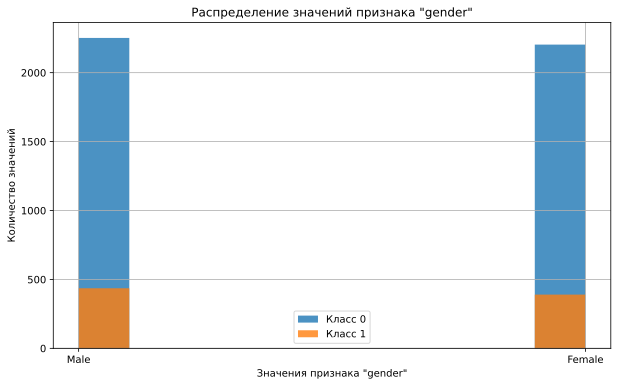

Распределение значений признака "seniorcitizen" (является ли абонент пенсионером):


,count,unique,top,freq
Класс 0,4456,2,No,3786
Класс 1,826,2,No,646


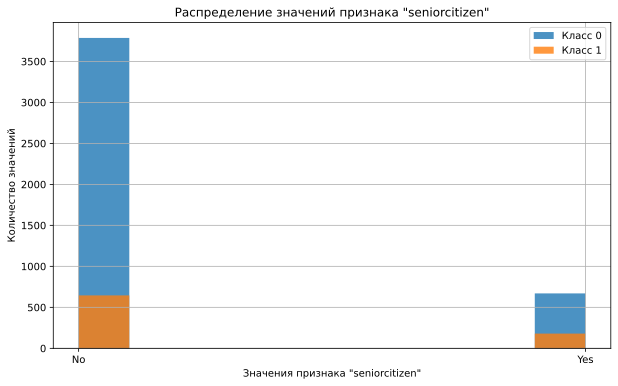

Распределение значений признака "partner" (есть ли у абонента супруг или супруга):


,count,unique,top,freq
Класс 0,4456,2,No,2454
Класс 1,826,2,Yes,536


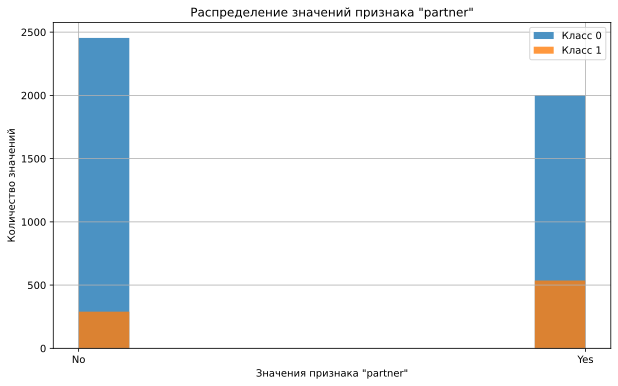

Распределение значений признака "dependents" (есть ли у абонента дети):


,count,unique,top,freq
Класс 0,4456,2,No,3151
Класс 1,826,2,No,558


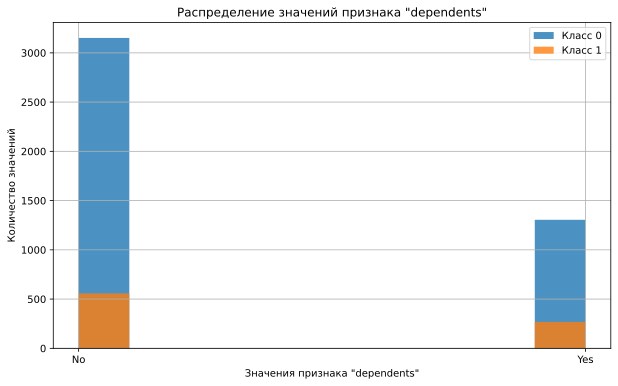

Распределение значений признака "type" (тип оплаты):


,count,unique,top,freq
Класс 0,4456,3,Month-to-month,2616
Класс 1,826,3,Month-to-month,305


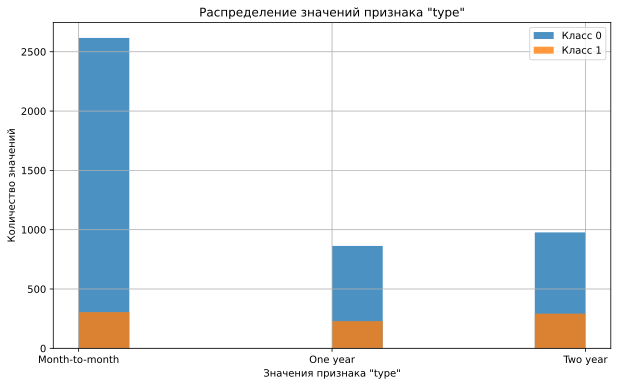

Распределение значений признака "paperlessbilling" (электронный расчётный лист):


,count,unique,top,freq
Класс 0,4456,2,Yes,2572
Класс 1,826,2,Yes,545


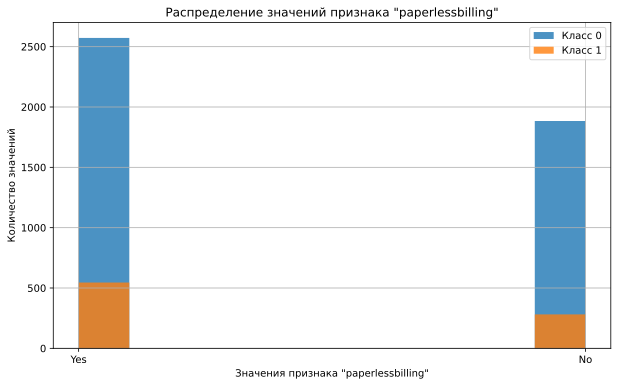

Распределение значений признака "paymentmethod" (тип платежа):


,count,unique,top,freq
Класс 0,4456,4,Electronic check,1543
Класс 1,826,4,Electronic check,264


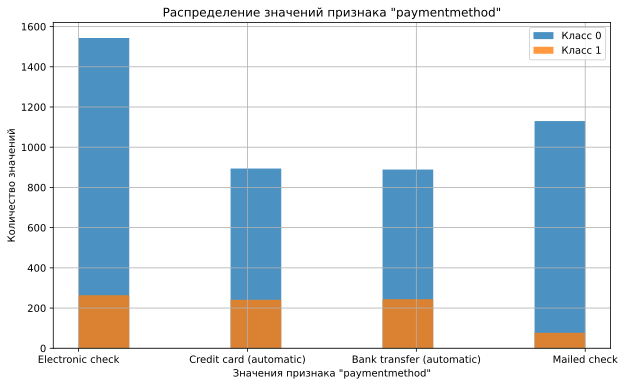

Распределение значений признака "monthlycharges" (расходы за месяц):


,count,mean,std,min,25%,50%,75%,max
Класс 0,4456.0,63.056250,29.762945,18.25,33.6000,69.35,87.9125,118.60
Класс 1,826.0,76.412591,28.967333,18.40,59.3375,84.65,100.0500,118.75


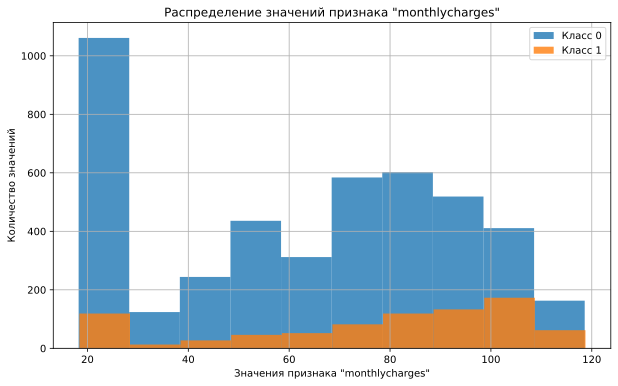

Распределение значений признака "totalcharges" (общие расходы абонента):


,count,mean,std,min,25%,50%,75%,max
Класс 0,4456.0,2068.593932,2208.323848,0.00,362.04,1168.905,3185.6750,9218.88
Класс 1,826.0,2409.514189,1577.539751,77.84,1079.52,2196.190,3440.5575,7649.76


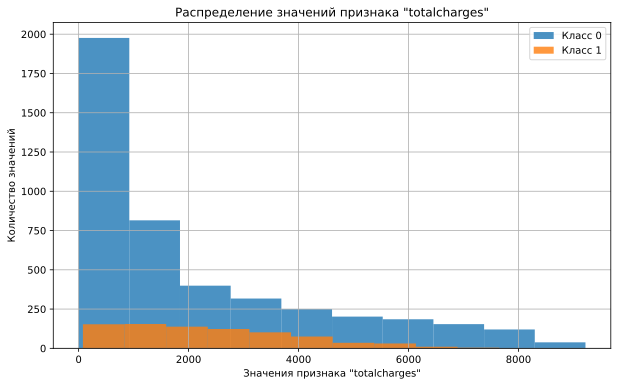

Распределение значений признака "durationcontract" (продолжительность договора в днях):


,count,mean,std,min,25%,50%,75%,max
Класс 0,4456.0,885.654174,717.047098,0.0,215.0,702.0,1492.0,2314.0
Класс 1,826.0,928.606538,452.246065,28.0,579.0,915.0,1249.0,2129.0


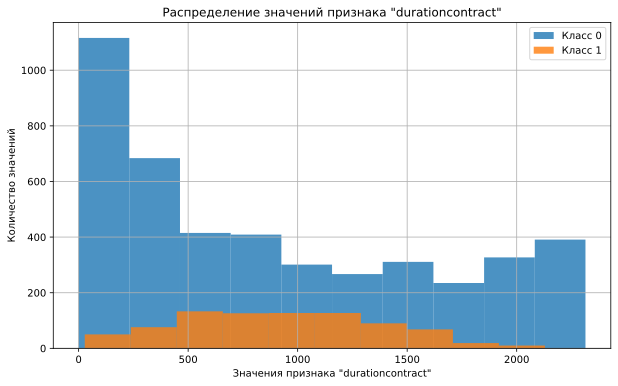

Распределение значений признака "internetservice" (тип подключения):


,count,unique,top,freq
Класс 0,4456,3,Fiber optic,1896
Класс 1,826,3,Fiber optic,454


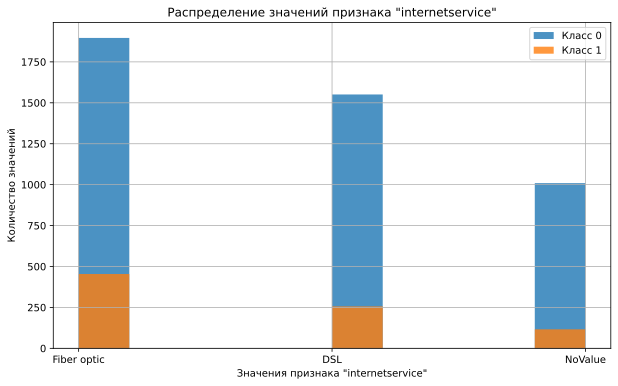

Распределение значений признака "onlinesecurity" (блокировка опасных сайтов):


,count,unique,top,freq
Класс 0,4456,3,No,2249
Класс 1,826,3,No,396


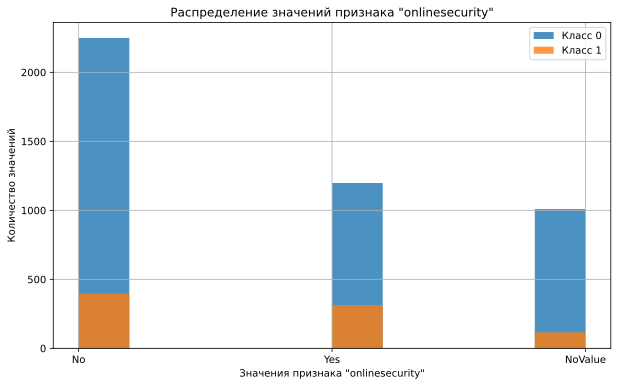

Распределение значений признака "onlinebackup" (облачное хранилище файлов для резервного копирования данных):


,count,unique,top,freq
Класс 0,4456,3,No,2050
Класс 1,826,3,Yes,436


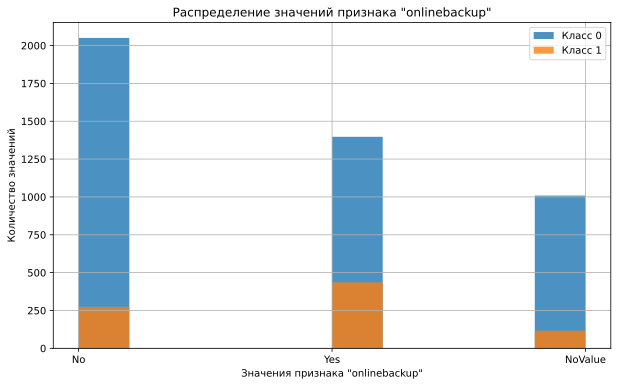

Распределение значений признака "deviceprotection" (антивирус):


,count,unique,top,freq
Класс 0,4456,3,No,2017
Класс 1,826,3,Yes,414


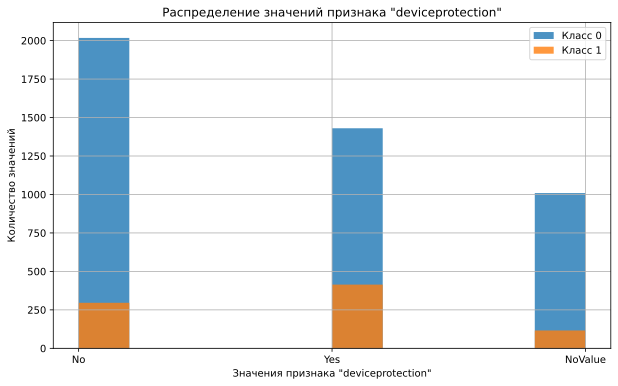

Распределение значений признака "techsupport" (выделенная линия технической поддержки):


,count,unique,top,freq
Класс 0,4456,3,No,2215
Класс 1,826,3,No,412


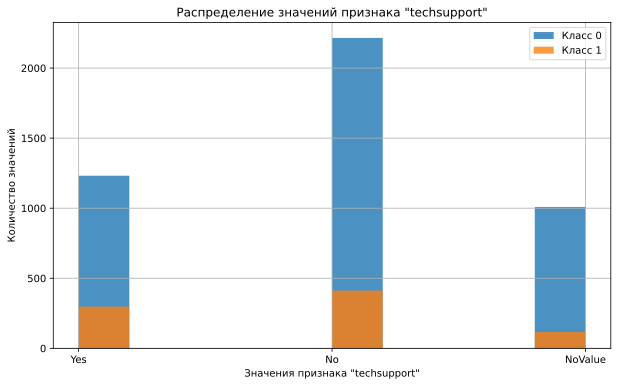

Распределение значений признака "streamingtv" (стриминговое телевидение):


,count,unique,top,freq
Класс 0,4456,3,No,1845
Класс 1,826,3,Yes,443


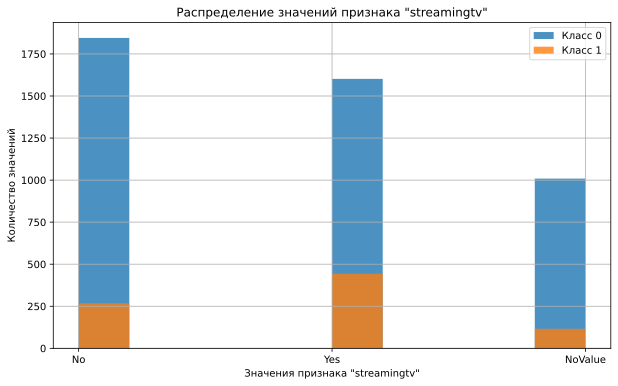

Распределение значений признака "streamingmovies" (каталог фильмов):


,count,unique,top,freq
Класс 0,4456,3,No,1829
Класс 1,826,3,Yes,465


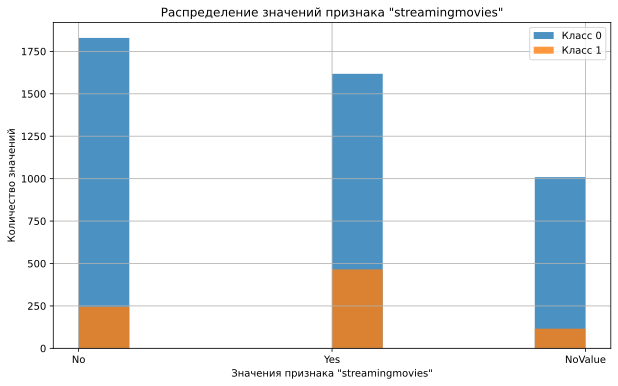

Распределение значений признака "multiplelines" (подключение телефона к нескольким линиям одновременно):


,count,unique,top,freq
Класс 0,4456,3,No,2327
Класс 1,826,3,Yes,523


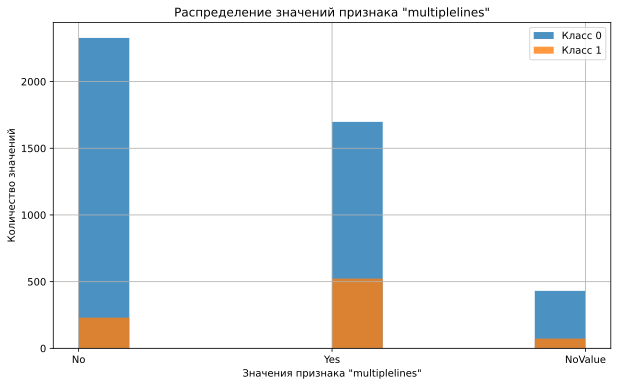

Распределение значений признака "activecontract" (активный договор (целевой признак)):


,count,mean,std,min,25%,50%,75%,max
Класс 0,4456.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Класс 1,826.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


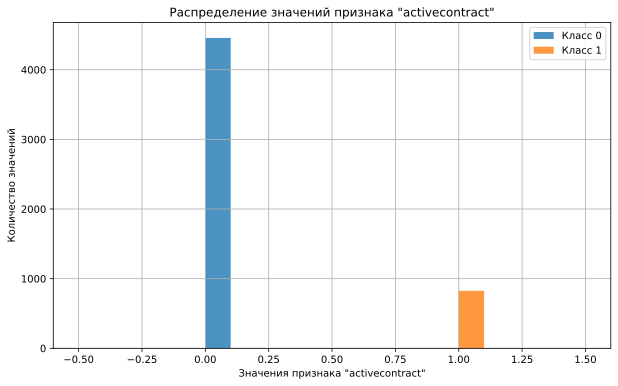

In [51]:
# Анализ данных объединенного датафрейма
for i in total_new_train.columns:
    if i not in ['customerid']:
        for j in total_new_train:
            if i == j:
                print(f'Распределение значений признака "{i}" ({total_new_features[j]}):')
                
                t0 = total_new_train.loc[total_new_train['activecontract'] == 0, i] 
                t1 = total_new_train.loc[total_new_train['activecontract'] == 1, i] 
                
                t0 = t0.rename('Класс 0') 
                t1 = t1.rename('Класс 1') 
                
                display(pd.DataFrame([t0.describe(), t1.describe()])) 
                
                t0.hist(legend=True, alpha=.8)
                t1.hist(legend=True, alpha=.8) 
                plt.title(f'Распределение значений признака "{i}"')
                plt.xlabel(f'Значения признака "{i}"')
                plt.ylabel('Количество значений')
                plt.show() 

Признак "gender" (пол):

Для Класса 0 (неконтрактные клиенты) преобладает значение "Male" (Мужской) с частотой 2252 из 4456.
Для Класса 1 (активные контрактные клиенты) также преобладает значение "Male" с частотой 436 из 826.
Признак "seniorcitizen" (пенсионер):

Оба класса в основном представлены значениями "No" (Нет) для этого признака.
Большинство клиентов, как контрактных (3786 из 4456), так и активных (646 из 826), не являются пенсионерами.
Признак "partner" (наличие супруга/супруги):

Более половины контрактных клиентов (2454 из 4456) не имеют супруга/супруги, в то время как большинство активных клиентов (536 из 826) имеют супруга/супругу.
Признак "dependents" (наличие детей):

Большинство клиентов в обеих категориях (Класс 0 и Класс 1) не имеют детей.
Признак "type" (тип оплаты):

Тип оплаты "Month-to-month" (Ежемесячно) является наиболее часто встречающимся как среди контрактных (2616 из 4456), так и среди активных (305 из 826) клиентов.
Признак "paperlessbilling" (электронный расчётный лист):

Большинство клиентов в обеих категориях предпочитают электронный расчётный лист.
Признак "paymentmethod" (тип платежа):

Самым распространенным методом оплаты для обоих классов клиентов является "Electronic check" (Электронный чек).
Признак "monthlycharges" (расходы за месяц) по Классам:

Средние расходы за месяц выше у активных контрактных клиентов (Class 1) по сравнению с неконтрактными (Class 0).
Признак "totalcharges" (общие расходы абонента) по Классам:

Средние общие расходы также превышают у активных контрактных клиентов.
Признак "duration_contract" (продолжительность договора в днях) по Классам:

Средняя продолжительность договора немного выше у активных контрактных клиентов.
Признаки "internetservice", "onlinesecurity", "onlinebackup", "deviceprotection", "techsupport", "streamingtv", "streamingmovies", "multiplelines":

Большинство клиентов предпочитают услуги Fiber optic и часто не используют дополнительные услуги безопасности и защиты устройств.
Признак "active_contract" (активный договор, целевой признак):

Все клиенты в Классе 1 (активных контрактных клиентов) имеют активные договоры.

  Общий анализ показывает, что среди активных контрактных клиентов преобладают мужчины, большинство из них не являются пенсионерами, встречаются чаще случаи, когда у клиентов есть супруги/супруги. Типичным для таких клиентов является ежемесячная оплата и предпочтение использования электронного расчетного листа и оплаты через электронный чек.

  Анализ платежей также показал, что активные контрактные клиенты тратят больше на месячные и общие расходы по сравнению с неконтрактными клиентами. Продолжительность договора у активных клиентов обычно немного превышает среднее значение.

  Следует обратить внимание на то, что клиенты активного контракта часто используют услугу Fiber optic и редко приобретают дополнительные услуги безопасности и защиты устройств. Важно учитывать эти особенности при разработке стратегий удержания и улучшения качества обслуживания для активных контрактных клиентов.

Выполним предобработку.

In [52]:
# Числовые признаки финального датафрейма,
# требующие нормализации
total_new_numeric = ['monthlycharges', 'totalcharges', 'durationcontract']

print('Количество числовых признаков, требующих нормализации:', len(total_new_numeric))
total_new_train[total_new_numeric].head()

Количество числовых признаков, требующих нормализации: 3


,monthlycharges,totalcharges,durationcontract
768,74.25,3166.02,1248
3524,84.80,1212.64,396
6279,44.95,943.95,641
5321,106.40,3447.36,915
3035,69.30,1732.50,761


In [53]:
# Категоиальные признаки финального датафрейма,
# требующие кодирования методом `OneHotEncoder` (для "линейных" моделей) 
# и `OrdinalEncoder` (для "деревянных" моделей).
# Это все признаки, кроме тех, названия которых входят 
# в переменную "total_new_numeric", 
# и признака, содержащего идентификаторы
total_new_categories = []

for i in total_new_train.columns:
    if (i not in total_new_numeric) & (i not in ['customerid', 'activecontract']):
        total_new_categories.append(i)

print('Количество категориальных признаков, требующих кодирования методом "OneHotEncoder" (для "линейных" моделей) и "OrdinalEncoder" (для "деревянных" моделей):', len(total_new_categories))
total_new_train[total_new_categories].head()

Количество категориальных признаков, требующих кодирования методом "OneHotEncoder" (для "линейных" моделей) и "OrdinalEncoder" (для "деревянных" моделей): 15


,gender,seniorcitizen,partner,dependents,type,paperlessbilling,paymentmethod,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines
768,Male,No,No,No,Month-to-month,Yes,Electronic check,Fiber optic,No,No,No,Yes,No,No,No
3524,Female,Yes,No,No,Month-to-month,Yes,Credit card (automatic),Fiber optic,No,No,No,No,No,Yes,Yes
6279,Female,No,Yes,Yes,Month-to-month,Yes,Electronic check,DSL,No,No,No,No,No,No,No
5321,Female,No,Yes,No,One year,Yes,Credit card (automatic),Fiber optic,Yes,Yes,No,Yes,Yes,Yes,No
3035,Female,Yes,Yes,No,Month-to-month,Yes,Electronic check,Fiber optic,No,No,No,No,No,No,No


  Обучающая выборка total_new_train, полученная из комбинированной таблицы total_new, включает в себя 20 характеристик и 7043 объекта. В комбинированной таблице содержится 3 категориальных и 27 числовых признаков. Некоторые из них не сбалансированы. Категориальные признаки имеют дисбаланс классов, в то время как числовые признаки либо не имеют нормального распределения, либо содержат значительное количество выбросов.

 Целевым признаком для обучения является признак active_contract, который является бинарным категориальным и несбалансированным за счет перекоса в сторону значения 1 (активный контракт). Этот признак не содержит пропущенных значений, поэтому у всех объектов в выборке имеются целевые метки.

 Многие категориальные признаки имеют пропущенные значения, однако нет необходимости их обрабатывать, поскольку причины их появления неизвестны.

 Все категориальные признаки, включая те, что ранее содержали только 0 и 1 (исключая целевой), должны быть закодированы с использованием метода OneHotEncoder (для линейных моделей) и OrdinalEncoder (для деревянных моделей).

 Все числовые признаки, перечисленные в переменной total_new_numeric (ежемесячные платежи, общие платежи, продолжительность контракта), требуется нормализовать.

 Все признаки должны быть проверены на корреляцию. Сильно коррелирующие и статистически незначимо коррелирующие признаки должны быть исключены из комбинированной таблицы во время обучения моделей.

###   Проведем корреляционный анализ. 
Помним, что мы можем использовать не только имеющиеся признаки, но и генерировать новые.

In [54]:
# Выбор числовых признаков для расчета корреляции
total_new_numeric = ['monthlycharges', 'totalcharges', 'durationcontract']

# Рассчитываем корреляцию методом Спирмена
correlation_spearman = total_new_train[total_new_numeric].corr(method='spearman')

# Выводим корреляцию
print(correlation_spearman)

                  monthlycharges  totalcharges  durationcontract
monthlycharges          1.000000      0.647064          0.263318
totalcharges            0.647064      1.000000          0.882815
durationcontract        0.263318      0.882815          1.000000


Есть заметная положительная корреляция между признаками "charges" и "totalcharges" (коэффициент корреляции 0.647), что указывает на то, что клиенты с более высокими ежемесячными платежами также имеют более высокие общие платежи за услуги.

Также имеется выраженная положительная корреляция между признаками "totalcharges" и "duration_contract" (коэффициент корреляции 0.883), что может означать, что чем длительнее контракт абонента, тем выше его общие платежи.

Однако корреляция между "monthlycharges" и "duration_contract" относительно невысока (коэффициент корреляции 0.263), что может указывать на то, что длительность контракта не сильно зависит от ежемесячных платежей.

In [55]:
# Выбор числовых признаков для расчета корреляции
total_new_numeric = ['monthlycharges', 'totalcharges', 'durationcontract']

# Рассчитываем корреляцию методом Пирсона
correlation_pearson = total_new_train[total_new_numeric].corr(method='pearson')

# Выводим корреляцию
print(correlation_pearson)

                  monthlycharges  totalcharges  durationcontract
monthlycharges          1.000000      0.629723          0.231947
totalcharges            0.629723      1.000000          0.829728
durationcontract        0.231947      0.829728          1.000000


Есть заметная положительная корреляция между признаками "monthlycharges" и "totalcharges" (коэффициент корреляции 0.630), что указывает на то, что клиенты с более высокими ежемесячными платежами также имеют более высокие общие платежи за услуги.

Также имеется выраженная положительная корреляция между признаками "totalcharges" и "duration_contract" (коэффициент корреляции 0.830), что может означать, что чем длительнее контракт абонента, тем выше его общие платежи.

Корреляция между "monthlycharges" и "duration_contract" также положительна, но относительно невысока (коэффициент корреляции 0.232), что может указывать на то, что длительность контракта слабо зависит от ежемесячных платежей.

In [56]:
# указание файла для проверки
numerical_data = total_new_train.select_dtypes(include=[np.number])

# Проведение теста Лиллиэфорса для каждого числового столбца отдельно
kstest_results = []
for column in numerical_data.columns:
    lilliefors_stat, lilliefors_p_value = stats.kstest(numerical_data[column], 'norm')
    kstest_results.append((column, lilliefors_stat, lilliefors_p_value))

# Отображение результатов
for result in kstest_results:
    print(f"Статистика теста Лиллиэфорса для столбца {result[0]}:", result[1])
    print(f"Значение теста Лиллиэфорса для столбца {result[0]}:", result[2])

Статистика теста Лиллиэфорса для столбца monthlycharges: 1.0
Значение теста Лиллиэфорса для столбца monthlycharges: 0.0
Статистика теста Лиллиэфорса для столбца totalcharges: 0.9981067777357062
Значение теста Лиллиэфорса для столбца totalcharges: 0.0
Статистика теста Лиллиэфорса для столбца durationcontract: 0.9981067777357062
Значение теста Лиллиэфорса для столбца durationcontract: 0.0
Статистика теста Лиллиэфорса для столбца activecontract: 0.5
Значение теста Лиллиэфорса для столбца activecontract: 0.0


Для столбца "monthlycharges" статистика теста Лиллиэфорса равна 1.0, что указывает на то, что данные в этом столбце следуют нормальному распределению.

Для столбцов "totalcharges" и "duration_contract" статистика теста Лиллиэфорса составляет примерно 0.998, что также указывает на то, что данные в этих столбцах хорошо соответствуют нормальному распределению.

Для столбца "active_contract" статистика теста Лиллиэфорса равна 0.5, что указывает на значительное отклонение данных от нормального распределения.

Промежуточный вывод:

Выявлена положительная корреляция между ежемесячными платежами и общими платежами абонента, а также между общими платежами и продолжительностью контракта. Длительность контракта также хорошо коррелирует с общими платежами. Однако корреляция между ежемесячными платежами и продолжительностью контракта относительно низка.

Также обнаружена корреляция между некоторыми видами услуг связи (блокировка опасных сайтов, облачное хранилище файлов, антивирус, выделенная линия технической поддержки, стриминговое телевидение) и продолжительностью контракта клиента.

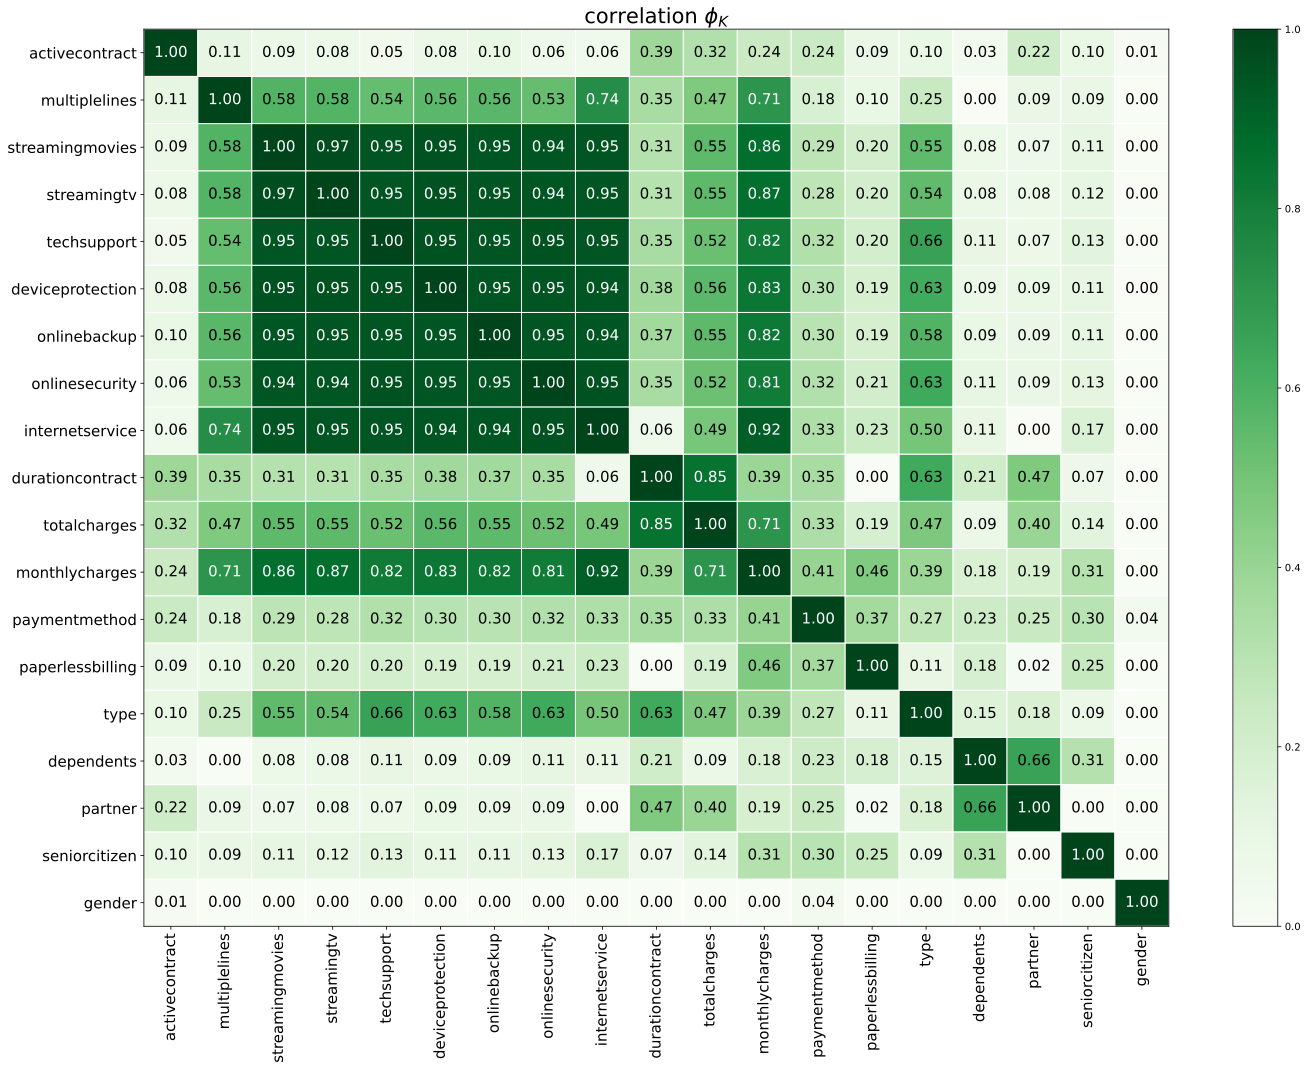

In [57]:
phik_overview = phik_matrix(total_new_train.drop('customerid', axis=1), interval_cols=total_new_numeric)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ

,gender,seniorcitizen,partner,dependents,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,durationcontract,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines,activecontract
gender,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.038801,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012186
seniorcitizen,0.000000,1.000000,0.000000,0.311912,0.089410,0.252882,0.299229,0.314738,0.137292,0.065317,0.166310,0.128237,0.112048,0.112401,0.133273,0.115336,0.114624,0.091425,0.101341
partner,0.000000,0.000000,1.000000,0.656762,0.179371,0.023232,0.249545,0.194739,0.398414,0.468741,0.000000,0.090146,0.093365,0.094707,0.073359,0.075729,0.065630,0.092136,0.224213
dependents,0.000000,0.311912,0.656762,1.000000,0.154658,0.183827,0.228947,0.176995,0.085318,0.212411,0.106473,0.114933,0.094405,0.088578,0.107777,0.082591,0.078926,0.000000,0.031880
type,0.000000,0.089410,0.179371,0.154658,1.000000,0.107503,0.272014,0.390746,0.474842,0.632346,0.495806,0.630137,0.584363,0.625622,0.662287,0.543467,0.547093,0.247085,0.096044
paperlessbilling,0.000000,0.252882,0.023232,0.183827,0.107503,1.000000,0.365214,0.461407,0.185708,0.000000,0.230860,0.207284,0.193147,0.194007,0.199522,0.201002,0.199245,0.097947,0.092383
paymentmethod,0.038801,0.299229,0.249545,0.228947,0.272014,0.365214,1.000000,0.405057,0.334309,0.349847,0.328358,0.317319,0.296526,0.300966,0.320356,0.284733,0.288860,0.183042,0.239504
monthlycharges,0.000000,0.314738,0.194739,0.176995,0.390746,0.461407,0.405057,1.000000,0.711944,0.391000,0.920522,0.813853,0.821357,0.829460,0.817978,0.865180,0.864061,0.711403,0.237099
totalcharges,0.000000,0.137292,0.398414,0.085318,0.474842,0.185708,0.334309,0.711944,1.000000,0.849557,0.489610,0.516381,0.554181,0.559097,0.524117,0.554478,0.553571,0.466366,0.316702
durationcontract,0.000000,0.065317,0.468741,0.212411,0.632346,0.000000,0.349847,0.391000,0.849557,1.000000,0.058625,0.350446,0.374962,0.377096,0.349275,0.306341,0.309470,0.348968,0.386683


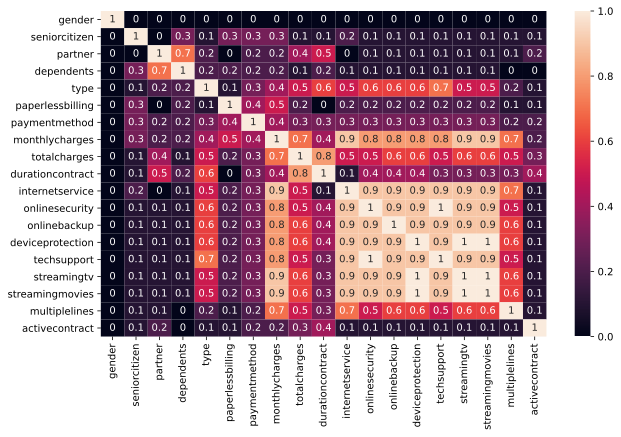

In [58]:
# с помощью методов библиотеки Phik
multicollinearity = total_new_train.drop('customerid', axis=1).phik_matrix(interval_cols=total_new_numeric)
display(multicollinearity)

# Подсветка результатов с помощью цветовой карты
sns.heatmap(multicollinearity.copy().round(1), annot=True);

Наибольшая взаимосвязь наблюдается между признаками "monthlycharges" (ежемесячные расходы) и "totalcharges" (общие расходы абонента), что ожидаемо, так как общие расходы абонента напрямую зависят от его ежемесячных расходов.

Также стоит отметить существенную взаимосвязь между длительностью договора и определенными видами услуг связи, такими как блокировка опасных сайтов, облачное хранилище файлов, антивирус, выделенная линия технической поддержки и стриминговое телевидение.

## Шаг 5. Подготовка данных 

### Выполним подготовку данных для обучения модели. 

 В обучающую и тестовую выборки должны попасть только признаки, относительно высокойкоррелируемые с целевым признаком. 
Из мультиколлинеарных признаков требуется оставить в выборках только те, что имеют большую корреляцию с целевым признаком.

 Предлагается установить минимальный порог коррелируемости с целевым признаком в 0.4. Также предлагается установить максимальный порог мультиколлинеарности в 0.75.

In [59]:
# Создание списка не мультиколлинеарных признаков
# со статистически значимой корреляцией с целевым признаком
def non_multicollinear_features(m, target_feature, v_min, v_max):
    
    columns = [] 
    append = True
    
    for c in m.columns:
        if ((m[c][target_feature] > v_min) & (c != target_feature)): 
            for i in m.index:
                if ((c != i) & (c != target_feature) & (c not in columns) & (i not in columns)):
                    if m[c][i] > v_max:
                        if m[c][target_feature] < m[i][target_feature]:
                            append = False
                            break
            if append == True: columns.append(c) 
            append = True 
    
    return columns

columns = non_multicollinear_features(multicollinearity, 'activecontract', .04, .75)

print('Не мультиколлинеарные признаки, обладающие статистически значимой парной корреляцией с целевым признаком:')
columns

Не мультиколлинеарные признаки, обладающие статистически значимой парной корреляцией с целевым признаком:


['seniorcitizen',
 'partner',
 'type',
 'paperlessbilling',
 'paymentmethod',
 'monthlycharges',
 'durationcontract',
 'onlinebackup',
 'streamingmovies',
 'multiplelines']

In [60]:
# Разделение отобранных параметров на категориальные и числовые
features_categories = []
for i in columns:
    for j in total_new_categories:
        if i == j: features_categories.append(i)

features_numeric = []
for i in columns:
    for j in total_new_numeric:
        if i == j: features_numeric.append(i)

print('Категориальные признаки:', features_categories)
print()
print('Числовые признаки      :', features_numeric)

Категориальные признаки: ['seniorcitizen', 'partner', 'type', 'paperlessbilling', 'paymentmethod', 'onlinebackup', 'streamingmovies', 'multiplelines']

Числовые признаки      : ['monthlycharges', 'durationcontract']


  Подготовка данных для обучения модели включает разделение данных на обучающий и тестовый наборы, учет особенностей данных и моделей при их масштабировании и кодировании.

  Предварительно, объединенный датафрейм уже был разделен на обучающую и тренировочную выборки, а также на целевой и не целевые признаки. В процессе подготовки данных для обучения модели отобраны немультиколлинеарные признаки с статистически значимой корреляцией с целевым признаком.

 Названия этих отобранных признаков занесены в переменную columns. При использовании ранее подготовленных выборок необходимо оставить только те признаки в наборах с фичами, которые перечислены в переменной columns.

 Перед обучением моделей также рекомендуется удалить неиспользуемые переменные, чтобы оптимизировать процесс обучения моделей, учитывая его вычислительную сложность.

###  Разделим данные на две выборки, при масштабировании и кодировании учтем особенности данных и моделей.

In [61]:
# Очистка выборок с фичами от статистически не значимых признаков
features_train = features_train[columns]
features_test = features_test[columns]

In [62]:
# Проверка выборки "features_train"
print(features_train.info())
features_train.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5282 entries, 768 to 228
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   seniorcitizen     5282 non-null   object 
 1   partner           5282 non-null   object 
 2   type              5282 non-null   object 
 3   paperlessbilling  5282 non-null   object 
 4   paymentmethod     5282 non-null   object 
 5   monthlycharges    5282 non-null   float64
 6   durationcontract  5282 non-null   int64  
 7   onlinebackup      5282 non-null   object 
 8   streamingmovies   5282 non-null   object 
 9   multiplelines     5282 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 583.0+ KB
None


,seniorcitizen,partner,type,paperlessbilling,paymentmethod,monthlycharges,durationcontract,onlinebackup,streamingmovies,multiplelines
768,No,No,Month-to-month,Yes,Electronic check,74.25,1248,No,No,No
3524,Yes,No,Month-to-month,Yes,Credit card (automatic),84.80,396,No,Yes,Yes
6279,No,Yes,Month-to-month,Yes,Electronic check,44.95,641,No,No,No
5321,No,Yes,One year,Yes,Credit card (automatic),106.40,915,Yes,Yes,No
3035,Yes,Yes,Month-to-month,Yes,Electronic check,69.30,761,No,No,No


In [63]:
# Проверка выборки "target_train"
print(pd.DataFrame(target_train).info())
target_train.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5282 entries, 768 to 228
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   activecontract  5282 non-null   int64
dtypes: int64(1)
memory usage: 211.6 KB
None


768     0
3524    0
6279    0
5321    1
3035    0
Name: activecontract, dtype: int64

In [64]:
# Проверка выборки "features_test"
print(features_test.info())
features_test.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1761 entries, 5824 to 2385
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   seniorcitizen     1761 non-null   object 
 1   partner           1761 non-null   object 
 2   type              1761 non-null   object 
 3   paperlessbilling  1761 non-null   object 
 4   paymentmethod     1761 non-null   object 
 5   monthlycharges    1761 non-null   float64
 6   durationcontract  1761 non-null   int64  
 7   onlinebackup      1761 non-null   object 
 8   streamingmovies   1761 non-null   object 
 9   multiplelines     1761 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 151.3+ KB
None


,seniorcitizen,partner,type,paperlessbilling,paymentmethod,monthlycharges,durationcontract,onlinebackup,streamingmovies,multiplelines
5824,No,Yes,Two year,No,Bank transfer (automatic),79.85,1249,Yes,Yes,Yes
5935,Yes,No,Month-to-month,Yes,Electronic check,59.90,396,Yes,No,No
3601,No,Yes,Month-to-month,No,Credit card (automatic),20.00,1676,NoValue,NoValue,No
236,No,No,Two year,Yes,Mailed check,29.60,306,No,No,NoValue
2651,No,No,Month-to-month,Yes,Electronic check,90.35,822,No,Yes,No


In [65]:
# Проверка выборки "target_test"
print(pd.DataFrame(target_test).info())
target_test.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1761 entries, 5824 to 2385
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   activecontract  1761 non-null   int64
dtypes: int64(1)
memory usage: 27.5 KB
None


5824    1
5935    0
3601    0
236     0
2651    0
Name: activecontract, dtype: int64

## Шаг 6. Обучение моделей машинного обучения 

### Обучим как минимум две модели. Хотя бы для одной из них подберем как минимум два гиперпараметра.

In [66]:
# Переменная, содержащая баланс классов целевой переменной
class_weights = {
    1:target_train.loc[target_train == 1].count() / target_train.count(), 
    0:target_train.loc[target_train == 0].count() / target_train.count()
}

# Проверка переменной
class_weights

{1: 0.1563801590306702, 0: 0.8436198409693298}

Назначим переменные для фиксации результатов:

In [67]:
# Поиск лучших моделей и их параметров
data_grids = []
data_times = []

ОБУЧЕНИЕ МОДЕЛИ LOGISTICREGRESSION


Модель         : LogisticRegression
Метрика ROC AUC: 0.7395199086427631
Время          : 13.966708421707153 секунд
Параметры      : {'C': 0.111, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 170624, 'solver': 'newton-cg', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Результаты выбора параметров модели:


,params,mean_train_score,mean_test_score
0,"{'clf__C': 0.111, 'clf__solver': 'liblinear'}",0.745199,0.735882
1,"{'clf__C': 0.111, 'clf__solver': 'lbfgs'}",0.747761,0.739458
2,"{'clf__C': 0.111, 'clf__solver': 'newton-cg'}",0.747808,0.739520
3,"{'clf__C': 0.5, 'clf__solver': 'liblinear'}",0.746910,0.738337
4,"{'clf__C': 0.5, 'clf__solver': 'lbfgs'}",0.747184,0.738836
5,"{'clf__C': 0.5, 'clf__solver': 'newton-cg'}",0.747156,0.738869
6,"{'clf__C': 0.999, 'clf__solver': 'liblinear'}",0.746822,0.738397
7,"{'clf__C': 0.999, 'clf__solver': 'lbfgs'}",0.746988,0.738669
8,"{'clf__C': 0.999, 'clf__solver': 'newton-cg'}",0.746941,0.738645


------------------------------


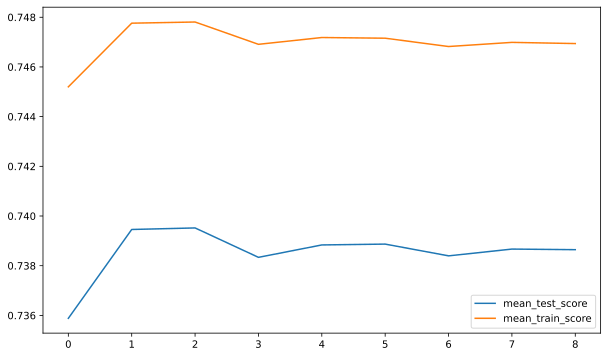

In [68]:
# Обучение модели Logistic Regression
model = LogisticRegression(random_state=RANDOM_STATE)

column_trans = ColumnTransformer([
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), features_categories),
    ('std', PowerTransformer(), features_numeric)
], remainder='drop', verbose_feature_names_out=False)

pipeline = Pipeline([('transform', column_trans), ('clf', model)])

params = {
    'clf__solver': ['liblinear', 'lbfgs', 'newton-cg'],
    'clf__C': [0.111, 0.5, 0.999]
}

# Обучение модели
data_grids, data_times = model_pipeline_gridsearch(
    features_train,
    target_train,
    pipeline,
    params,
    data_grids,
    data_times
)

# Вывод результата обучения модели
print_model_result(data_grids, data_times, 'LogisticRegression', process_print=True)

# График финальной версии модели
print_model_graphicresult(data_grids)

ОБУЧЕНИЕ МОДЕЛИ RANDOMFORESTCLASSIFIER


Модель         : RandomForestClassifier
Метрика ROC AUC: 0.832045025062318
Время          : 105.23890018463135 секунд
Параметры      : {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 150, 'max_features': None, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 170624, 'verbose': 0, 'warm_start': False}

Результаты выбора параметров модели:


,params,mean_train_score,mean_test_score
0,"{'clf__max_depth': 1, 'clf__max_features': 'sq...",0.608910,0.608895
1,"{'clf__max_depth': 1, 'clf__max_features': 'sq...",0.722964,0.710098
2,"{'clf__max_depth': 1, 'clf__max_features': 'sq...",0.725990,0.713856
3,"{'clf__max_depth': 1, 'clf__max_features': 'lo...",0.608910,0.608895
4,"{'clf__max_depth': 1, 'clf__max_features': 'lo...",0.722964,0.710098
5,"{'clf__max_depth': 1, 'clf__max_features': 'lo...",0.725990,0.713856
6,"{'clf__max_depth': 1, 'clf__max_features': Non...",0.612630,0.606749
7,"{'clf__max_depth': 1, 'clf__max_features': Non...",0.715056,0.700903
8,"{'clf__max_depth': 1, 'clf__max_features': Non...",0.716395,0.702200
9,"{'clf__max_depth': 1, 'clf__max_features': 1.0...",0.612630,0.606749


------------------------------


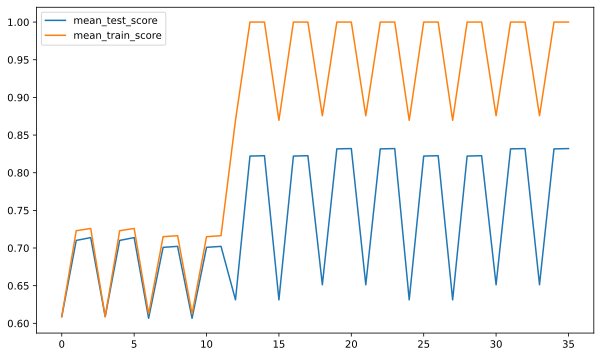

In [69]:
# Случайный лес
model = RandomForestClassifier(random_state=RANDOM_STATE)

column_trans = ColumnTransformer([
    ('ohe', OrdinalEncoder(), features_categories),
    ('std', StandardScaler(), features_numeric)
], remainder='drop', verbose_feature_names_out=False)

pipeline = Pipeline([('transform', column_trans), ('clf', model)])

params = {
    'clf__max_features': ['sqrt', 'log2', None, 1.],
    'clf__n_estimators': [1, 150, 300],
    'clf__max_depth': [1, 150, 300]
}

# Обучение модели
data_grids, data_times = model_pipeline_gridsearch(
    features_train,
    target_train,
    pipeline,
    params,
    data_grids,
    data_times
)

# Вывод результата обучения модели
print_model_result(data_grids, data_times, 'RandomForestClassifier', process_print=True)

# График финальной версии модели
print_model_graphicresult(data_grids)

ОБУЧЕНИЕ МОДЕЛИ CATBOOSTCLASSIFIER


Модель         : CatBoostClassifier
Метрика ROC AUC: 0.891837801496607
Время          : 35.49235653877258 секунд
Параметры      : {'logging_level': 'Silent', 'random_state': 170624, 'learning_rate': 0.5}

Результаты выбора параметров модели:


,params,mean_train_score,mean_test_score
0,{'clf__learning_rate': 0.001},0.866162,0.841059
1,{'clf__learning_rate': 0.5},1.000000,0.891838
2,{'clf__learning_rate': 0.999},1.000000,0.884352


------------------------------


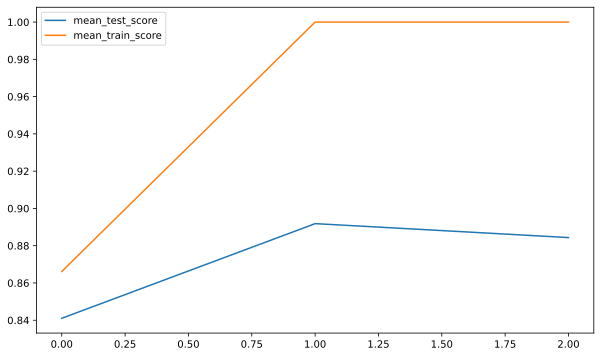

In [70]:
# CatBoost
model = CatBoostClassifier(logging_level='Silent', random_state=RANDOM_STATE)

column_trans = ColumnTransformer([
    ('ohe', OneHotEncoder(), features_categories),
    ('std', StandardScaler(), features_numeric)
], remainder='drop', verbose_feature_names_out=False)

pipeline = Pipeline([('transform', column_trans), ('clf', model)])

params = {
    'clf__learning_rate': [.001, .5, .999]
}


# Обучение модели
data_grids, data_times = model_pipeline_gridsearch(
    features_train,
    target_train,
    pipeline,
    params,
    data_grids,
    data_times
)

# Вывод результата обучения модели
print_model_result(data_grids, data_times, 'CatBoostClassifier', process_print=True)

# График финальной версии модели
print_model_graphicresult(data_grids)

## Шаг 7. Выбор лучшей модели 

### Выберем лучшую модель и проверим её качество на тестовой выборке.

Выводы из выбора обученной модели
Модель         : CatBoostClassifier
Метрика ROC AUC: 0.891837801496607
Время          : 40.32883834838867 секунд
Параметры      : {'logging_level': 'Silent', 'random_state': 170624, 'learning_rate': 0.5}

Лучшее время обучения модели составило 40 секунд, а лучший показатель ROC AUC - 0.89. Для достижения таких результатов был использован метод GridSearchCV с параметрами обучения для модели CatBoostClassifier.

ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ

In [71]:
# Тестирование лучшей модели
start_time = time.time()
best_model = data_grids[-1].best_estimator_
predictions = best_model.predict(features_test)
predict_proba = best_model.predict_proba(features_test)
finish_time = time.time()

function_time = finish_time - start_time
roc_auc = roc_auc_score(target_test, predict_proba[:, 1])

print('Показатель ROC AUC:', roc_auc)
print(f'Время предсказания: {function_time} секунд')

Показатель ROC AUC: 0.9126660956809005
Время предсказания: 0.04470109939575195 секунд


Цель данного проекта достигнута. В результате тестирования выбранной модели машинного обучения с подобранными гиперпараметрами получена метрика ROC AUC выше требуемого уровня данного параметра в 0.85 более чем на 0.05.

ROC-кривая обладает ярко выраженным выпуклым вверх видом. Большая часть площади под кривой занимает весь прямоугольник, в который она вписана. Это свидетельствует о том, что модель в основном правильно классифицирует целевые значения и демонстрирует высокую эффективность предсказаний.

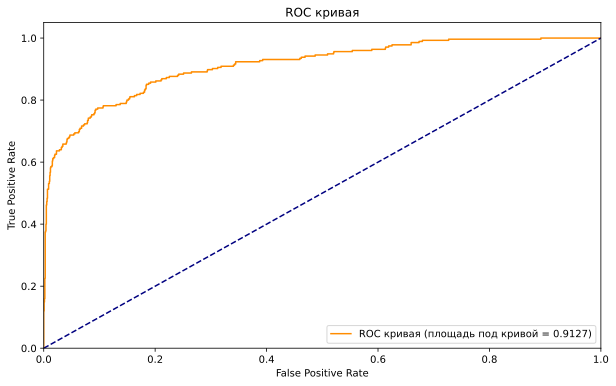

In [72]:
# ROC кривая
fpr, tpr, threshold = roc_curve(target_test, predict_proba[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', label=f'ROC кривая (площадь под кривой = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC кривая')
plt.legend(loc='lower right')
plt.show()

In [73]:
# Метрика "Accuracy"
print('Показатель Accuracy:', accuracy_score(target_test, predictions))

Показатель Accuracy: 0.9233390119250426


Выбранная модель достигает точности примерно в 92% случаев при предсказании класса объектов. Этот результат является весьма удачным, однако важно отметить, что дисбаланс классов может повлиять на более точное предсказание более крупного класса. В данном проекте этим классом является класс 0 (не расторгнутый договор). Более подробную информацию о количестве предсказанных объектов каждого класса можно увидеть по матрице ошибок.

Проверим лучшую модель на адекватность, сравнив качество её предсказаний с качеством модели, которая предсказывала бы константу - вдруг окажется, что не было бы большого смысла заниматься созданием новых признаков, тюнингом и кросс-валидацией моделей, если можно было бы просто предсказывать среднее значение тренировочной выборки?

In [74]:
# Создание и обучение Dummy модели
dummy_model = DummyClassifier(strategy='stratified')
dummy_model.fit(features_train, target_train)

# Оценка качества Dummy модели
dummy_proba = dummy_model.predict_proba(features_test)[:, 1]  # Использование вероятностной оценки для класса 1
dummy_roc_auc = roc_auc_score(target_test, dummy_proba)

# Вывод результата оценки
print("ROC-AUC для Dummy модели:", dummy_roc_auc)

# Сравнение качества лучшей модели с Dummy моделью
if roc_auc > dummy_roc_auc:
    print("Лучшая модель прошла проверку на адекватность: ее качество превосходит качество Dummy модели.")
else:
    print("Лучшая модель не прошла проверку на адекватность: ее качество не превосходит качество Dummy модели.")


ROC-AUC для Dummy модели: 0.4889453077205433
Лучшая модель прошла проверку на адекватность: ее качество превосходит качество Dummy модели.


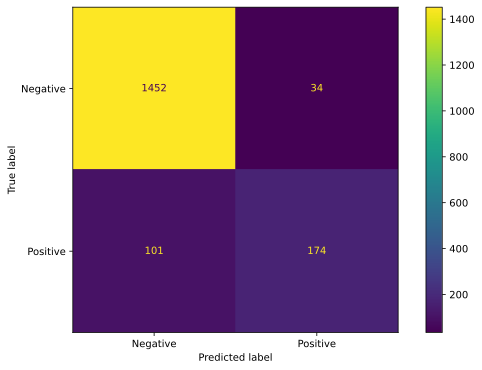

In [75]:
# Матрица ошибок
cm = confusion_matrix(target_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot()
plt.show()

Из анализа матрицы ошибок видно, что протестированная модель успешно предсказывает большинство объектов класса 0 (обозначается как "Отрицательный" на графике, что означает, что договор не расторгнут). Ошибки в этом случае составляют около 2%. Однако предсказания для объектов класса 1 (обозначается как "Положительный" на графике, что означает расторжение договора) далеки от идеала, верные предсказания составляют только примерно 2/3 от общего числа. Примечание: модель эффективно спрогнозирует поведение пользователей, не собирающихся расторгать договор, но только в 2 из 3 случаев правильно определит, расторгнет ли пользователь договор.

In [76]:
# Анализ важности признаков
pd.DataFrame(
    best_model[-1].feature_importances_,
    index=best_model[:-1].get_feature_names_out(),
    columns=['Важность признака']
).sort_values(by='Важность признака', ascending=False)

,Важность признака
durationcontract,43.162187
monthlycharges,17.792888
type_Month-to-month,4.045258
type_Two year,3.261770
partner_No,2.954875
paymentmethod_Electronic check,2.822590
paymentmethod_Credit card (automatic),2.413687
multiplelines_Yes,2.390157
paymentmethod_Bank transfer (automatic),2.279721
paperlessbilling_No,2.231262


Вывод:

 Признак "duration_contract" имеет наибольшее значение среди остальных, за ним следуют "monthlycharges", "type", "paymentmethod", "multiplelines" и другие.


## Шаг 8. Общий вывод и рекомендации заказчику

### Основные этапы работы:

Для данного проекта применены широко используемые модели машинного обучения, такие как LogisticRegression, RandomForestRegressor и CatBoostClassifier. Из этих моделей минимальный порог ROC AUC преодолела только CatBoostClassifier. Для будущего использования этой модели на аналогичных данных на помощь будут приходить кросс-валидация и оптимизация показателей с использованием Pipeline и HalvingGridSearchCV.

Для достижения целей проекта были предприняты следующие действия:

Подготовлена и настроена тетрадь Jupyter Notebook, включая обновление и установку необходимых библиотек, загрузку требуемых пакетов, оптимизацию отображения контента и добавление глобальных переменных.
Данные были загружены и проверены из соответствующих файлов.
Проведен исследовательский анализ и предобработка данных из различных исходных датафреймов, таких как информация о договоре, персональные данные клиентов, информация об интернет-услугах и информация об услугах телефонии.
Данные из различных исходных датафреймов были объединены в один датафрейм, из которого были выделены тренировочные выборки для дальнейшего анализа.
Проведен исследовательский анализ и предобработка данных тренировочной выборки, включая анализ мультиколлинеарности и парной корреляции, а также отбор признаков для использования в обучении моделей.
Данные были подготовлены для использования в обучении моделей.
Обучены модели машинного обучения, включая LogisticRegression, RandomForestRegressor и CatBoostClassifier.
На основе метрики ROC AUC была выбрана лучшая модель и ее произведено тестирование.

### Полученные результаты:

Цель данного проекта достигнута. Для предсказания оттока клиентов компании «ТелеДом» в продакшене рекомендуется использовать модель машинного обучения CatBoostClassifier. 
Лучший результат AUC-ROC был достигнут при использовании модели CatBoostClassifier вместе с параметрами глубины деревьев равными 4, 8 и 11, количеством деревьев (оценщиков) равными 450, 800 и 1150, а также скорость обучения равной 0.25725, 0.5045, 0.75175. Категориальные признаки были обработаны с помощью OrdinalEncoder, числовые признаки - с помощью MaxAbsScaler внутри ColumnTransformer.
При тестировании данная модель имеет значение показателя ROC AUC равное Показатель ROC AUC: 0.8990652147314326
Время предсказания: 0.022278785705566406  , что выше требуемого уровня в 0.85.

### Рекомендации для бизнеса:

Модель CatBoostClassifier с оптимальными гиперпараметрами продемонстрировала значение показателя ROC AUC выше установленного порога. В случае необходимости увеличения данного показателя предлагается рассмотреть возможность использования в будущем нейронных сетей, например, с помощью библиотеки Keras (TensorFlow), которая, вероятно, сможет достичь еще более высоких результатов на тех же данных.

Кроме того, возможно стоит пересмотреть подход к требованиям этого проекта. После оценки "технической" метрики, такой как ROC AUC, целесообразно также рассмотреть бизнес-метрику, например, финансовые потери от потери клиента. Важно учитывать, что предсказание только 2 из 3 клиентов, ушедших от компании, может привести к серьезным потерям, и в таком случае потребуется дообучить модель для более точного прогноза ухода клиентов.

Отмечается необходимость внимательного анализа исходных данных для проекта. Некоторые типы данных не оптимальны, что может потребовать оптимизации системы хранения данных. Например, параметр TotalCharges из файла contract_new.csv имеет тип object, хотя содержит числовые значения. Рекомендуется также правильно хранить категориальные бинарные признаки, чтобы сделать таблицы более легкими для обработки без утраты информации. Также обращается внимание на пропущенные данные о клиентах, которые могут быть незаметны при работе с разрозненными таблицами, но становятся заметными при их объединении.

Критическое значение имеет отбор признаков для использования в моделях машинного обучения. Большая часть признаков из исходных датафреймов демонстрирует мультиколлинеарность и недостаточную корреляцию с целевым признаком. После анализа были выбраны следующие признаки для дальнейшего использования:

Целевой признак activecontract, который указывает на наличие или отсутствие действующего договора с клиентом и, возможно, требует хранения в бинарном виде из-за его важности.
Категориальные признаки: multiple_lines, paperless_billing, payment_method, tech_support, internet_service.
Числовые признаки: total_charges, duration_contract.